# Credit Card Fraud Detection using Machine Learning

**Lakshay** &nbsp;|&nbsp; Roll No: AP24110010677 &nbsp;|&nbsp; B.Tech CSE
&nbsp;|&nbsp; SRM University - AP
Supervisor: Mr. Ajay Dilip Kumar Marapatla

> Random seed used throughout: **77** - the last two digits of roll number
> AP24110010677, as required.

---

# Notebook 07 - Artificial Neural Networks

**Syllabus coverage - UNIT IV**

| Topic from the unitization plan | Where it appears below |
|---|---|
| ANN: Introduction, Biological motivation, ANN representation | Section 1 |
| Appropriate problems for ANN learning | Section 2 |
| McCulloch-Pitts neuron | Section 3 |
| Perceptron, Perceptron learning | Section 4 |
| Implementation of logic gates using perceptron | Section 5 |
| Problem with perceptron | Section 6 |
| Gradient descent algorithm | Section 7 |
| Multilayer networks and the back propagation algorithm | Sections 8-9 |
| Computational Learning Theory, VC dimension | Section 11 |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import utils
from utils import SEED

print(utils.HEADER)
df = utils.load_data()
X_train, X_test, y_train, y_test = utils.make_split(df)


Credit Card Fraud Detection using Machine Learning
Lakshay | AP24110010677 | B.Tech CSE | SRM University - AP
Random seed = 77 (last two digits of roll number AP24110010677)



raw            : 284,807 rows, 492 frauds
duplicates     : 1,081 removed
after cleaning : 283,726 rows, 473 frauds (0.1667%)
train : 198,608 rows, 331 frauds
test  : 85,118 rows, 142 frauds


## 1. Biological motivation and ANN representation

An artificial neural network is loosely inspired by the brain. A biological
neuron receives signals through dendrites, sums them in the cell body, and fires
along its axon if the total exceeds a threshold. The artificial analogue keeps
the structure and discards the biology:

| Biological | Artificial |
|---|---|
| Dendrites | Input connections $x_1 \ldots x_n$ |
| Synaptic strength | Weights $w_1 \ldots w_n$ |
| Cell body summation | $\sum w_i x_i + b$ |
| Firing threshold | Activation function |
| Axon output | Output value |

A network arranges these units in layers: an **input layer** (one unit per
attribute), one or more **hidden layers**, and an **output layer**. Information
flows forward; learning happens by adjusting the weights.

## 2. Appropriate problems for ANN learning

ANN learning suits problems where:

- instances are attribute-value vectors, possibly with correlated attributes -
  **satisfied**;
- the target function may be discrete, real or vector valued - **satisfied**;
- the training data may contain noise - **satisfied**;
- long training times are acceptable - **acceptable here**, though ANNs are by
  far the slowest to train of the models in this project;
- fast evaluation of the learned function is required - **satisfied**, a forward
  pass is a handful of matrix multiplications;
- **human understanding of the learned function is not important** - this is the
  one that does not hold well for fraud detection, where a bank may have to
  justify a declined transaction. A network's weights are not readable the way a
  decision tree is.

## 3. The McCulloch-Pitts neuron

The earliest model of a neuron (1943). Inputs are binary, weights are fixed
rather than learned, and the unit fires when the weighted sum reaches a
threshold $\theta$:

$$ y = \begin{cases} 1 & \text{if } \sum_i w_i x_i \ge \theta \\
                      0 & \text{otherwise} \end{cases} $$

It has no learning rule at all - the weights must be set by hand. Below, an M-P
neuron is constructed by hand for the AND and OR functions.

In [2]:
def mcculloch_pitts(inputs, weights, theta):
    """A single McCulloch-Pitts unit: fires when the weighted sum reaches theta."""
    return int(np.dot(inputs, weights) >= theta)

X_logic = np.array([[0,0],[0,1],[1,0],[1,1]])

print("McCULLOCH-PITTS NEURON - AND function")
print("  weights w = [1, 1], threshold theta = 2\n")
print("   x1  x2 | sum | output | expected")
print("  " + "-"*38)
for x in X_logic:
    s = int(np.dot(x, [1,1]))
    out = mcculloch_pitts(x, [1,1], 2)
    print(f"   {x[0]}   {x[1]}  |  {s}  |   {out}    |    {x[0] & x[1]}")

print("\nMcCULLOCH-PITTS NEURON - OR function")
print("  weights w = [1, 1], threshold theta = 1\n")
print("   x1  x2 | sum | output | expected")
print("  " + "-"*38)
for x in X_logic:
    s = int(np.dot(x, [1,1]))
    out = mcculloch_pitts(x, [1,1], 1)
    print(f"   {x[0]}   {x[1]}  |  {s}  |   {out}    |    {x[0] | x[1]}")

McCULLOCH-PITTS NEURON - AND function
  weights w = [1, 1], threshold theta = 2

   x1  x2 | sum | output | expected
  --------------------------------------
   0   0  |  0  |   0    |    0
   0   1  |  1  |   0    |    0
   1   0  |  1  |   0    |    0
   1   1  |  2  |   1    |    1

McCULLOCH-PITTS NEURON - OR function
  weights w = [1, 1], threshold theta = 1

   x1  x2 | sum | output | expected
  --------------------------------------
   0   0  |  0  |   0    |    0
   0   1  |  1  |   1    |    1
   1   0  |  1  |   1    |    1
   1   1  |  2  |   1    |    1


## 4. The perceptron and the perceptron learning rule

The perceptron (Rosenblatt, 1958) adds two things the M-P neuron lacks: real
valued weights including a bias, and a **learning rule** that finds those
weights from examples.

Output:
$$ o(x) = \begin{cases} 1 & \text{if } w \cdot x + b > 0 \\ 0 & \text{otherwise} \end{cases} $$

Learning rule - for each training example, adjust every weight by

$$ w_i \leftarrow w_i + \eta \, (t - o) \, x_i $$

where $t$ is the target, $o$ the output and $\eta$ the learning rate. If the
prediction is correct, $t - o = 0$ and nothing changes. If it is wrong, the
weights move in the direction that corrects the error.

**The perceptron convergence theorem** guarantees that if the training data is
linearly separable, this rule finds a separating hyperplane in a finite number
of steps.

In [3]:
class Perceptron:
    """The perceptron learning rule, implemented directly from the definition."""
    def __init__(self, lr=0.1, epochs=20, seed=SEED):
        self.lr, self.epochs, self.seed = lr, epochs, seed

    def fit(self, X, y, verbose=False):
        rng = np.random.default_rng(self.seed)
        X = np.asarray(X, dtype=float); y = np.asarray(y, dtype=int)
        self.w = rng.normal(0, 0.01, X.shape[1])
        self.b = 0.0
        self.errors_ = []
        for ep in range(self.epochs):
            errs = 0
            for xi, target in zip(X, y):
                out = self.predict_one(xi)
                update = self.lr * (target - out)
                if update != 0.0:
                    self.w += update * xi
                    self.b += update
                    errs += 1
            self.errors_.append(errs)
            if verbose:
                print(f"  epoch {ep+1:>2} : {errs} weight updates   "
                      f"w = {np.round(self.w, 3)}  b = {self.b:.3f}")
            if errs == 0:
                if verbose: print("  converged - no misclassified examples remain")
                break
        return self

    def predict_one(self, x):
        return int(np.dot(x, self.w) + self.b > 0)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in np.asarray(X, dtype=float)])

## 5. Implementation of logic gates using a perceptron

In [4]:
gates = {
    "AND": np.array([0,0,0,1]),
    "OR":  np.array([0,1,1,1]),
    "NAND":np.array([1,1,1,0]),
    "NOR": np.array([1,0,0,0]),
}

for name, y_gate in gates.items():
    print(f"\n{'='*52}")
    print(f"PERCEPTRON LEARNING THE {name} GATE")
    print(f"{'='*52}")
    p = Perceptron(lr=0.1, epochs=20).fit(X_logic, y_gate, verbose=True)
    pred = p.predict(X_logic)
    print(f"\n   x1  x2 | target | perceptron output")
    print("  " + "-"*40)
    for x, t, o in zip(X_logic, y_gate, pred):
        mark = "ok" if t == o else "WRONG"
        print(f"   {x[0]}   {x[1]}  |   {t}    |        {o}          {mark}")
    print(f"\n  learned weights : w = {np.round(p.w, 4)}, b = {p.b:.4f}")
    print(f"  all correct     : {np.array_equal(pred, y_gate)}")


PERCEPTRON LEARNING THE AND GATE
  epoch  1 : 2 weight updates   w = [0.004 0.094]  b = 0.000
  epoch  2 : 2 weight updates   w = [0.104 0.094]  b = 0.000
  epoch  3 : 3 weight updates   w = [0.104 0.094]  b = -0.100
  epoch  4 : 2 weight updates   w = [0.104 0.194]  b = -0.100
  epoch  5 : 2 weight updates   w = [0.204 0.194]  b = -0.100
  epoch  6 : 3 weight updates   w = [0.204 0.194]  b = -0.200
  epoch  7 : 2 weight updates   w = [0.204 0.294]  b = -0.200
  epoch  8 : 1 weight updates   w = [0.204 0.194]  b = -0.300
  epoch  9 : 0 weight updates   w = [0.204 0.194]  b = -0.300
  converged - no misclassified examples remain

   x1  x2 | target | perceptron output
  ----------------------------------------
   0   0  |   0    |        0          ok
   0   1  |   0    |        0          ok
   1   0  |   0    |        0          ok
   1   1  |   1    |        1          ok

  learned weights : w = [0.2043 0.1943], b = -0.3000
  all correct     : True

PERCEPTRON LEARNING THE OR GATE


saved figure -> Results/figures/07_perceptron_logic_gates.png


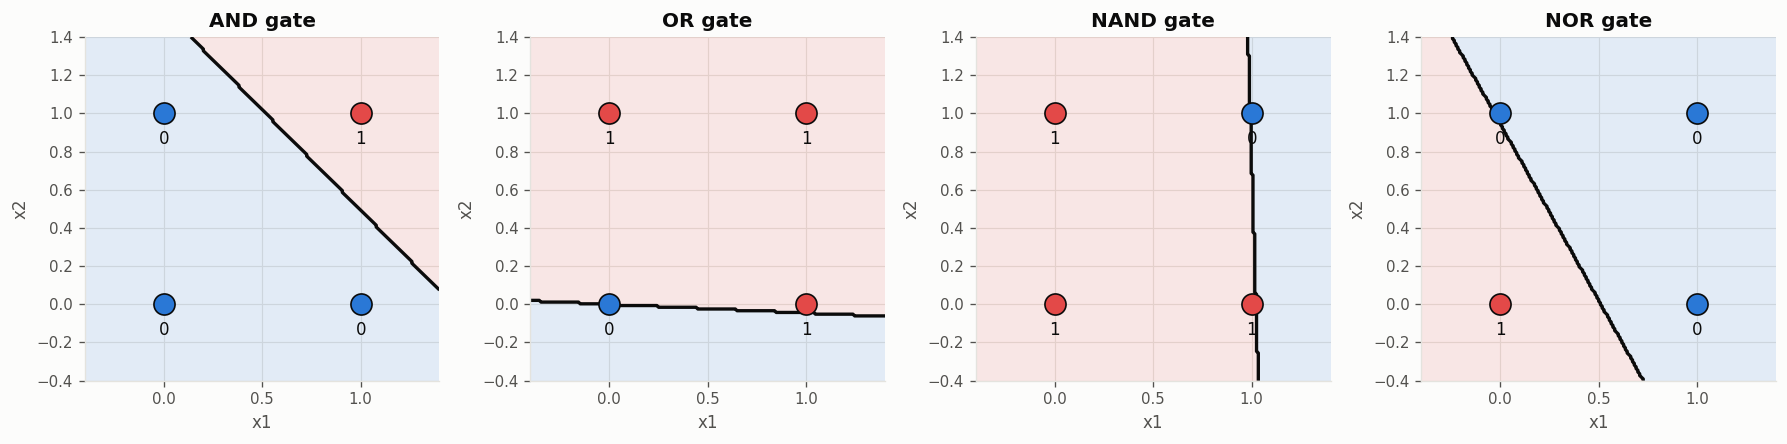

In [5]:
# Show the learned decision boundary for each gate
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, (name, y_gate) in zip(axes, gates.items()):
    p = Perceptron(lr=0.1, epochs=20).fit(X_logic, y_gate)
    xx, yy = np.meshgrid(np.linspace(-0.4, 1.4, 200), np.linspace(-0.4, 1.4, 200))
    Z = (np.c_[xx.ravel(), yy.ravel()] @ p.w + p.b > 0).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=[utils.BLUE, utils.RED],
                alpha=0.12)
    ax.contour(xx, yy, Z, levels=[0.5], colors=[utils.INK], linewidths=2)
    for x, t in zip(X_logic, y_gate):
        ax.scatter(x[0], x[1], s=160, color=utils.RED if t else utils.BLUE,
                   edgecolor=utils.INK, zorder=5)
        ax.text(x[0], x[1]-0.16, str(t), ha="center", fontsize=10, color=utils.INK)
    ax.set_title(f"{name} gate"); ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_xlim(-0.4, 1.4); ax.set_ylim(-0.4, 1.4)
    utils.despine(ax)
plt.tight_layout()
utils.save_fig(fig, "07_perceptron_logic_gates.png")
plt.show()

## 6. The problem with the perceptron - XOR

A single perceptron can only represent **linearly separable** functions, because
its decision boundary is a single hyperplane. AND, OR, NAND and NOR are all
linearly separable, so all four were learned.

**XOR is not.** No straight line can separate {(0,1), (1,0)} from {(0,0), (1,1)}.
This limitation, published by Minsky and Papert in 1969, halted neural network
research for over a decade.

In [6]:
y_xor = np.array([0,1,1,0])
print("PERCEPTRON ATTEMPTING THE XOR GATE")
print("="*52)
p_xor = Perceptron(lr=0.1, epochs=30).fit(X_logic, y_xor, verbose=True)
pred = p_xor.predict(X_logic)
print(f"\n   x1  x2 | target | perceptron output")
print("  " + "-"*40)
for x, t, o in zip(X_logic, y_xor, pred):
    print(f"   {x[0]}   {x[1]}  |   {t}    |        {o}          "
          f"{'ok' if t == o else 'WRONG'}")
print(f"\n  all correct : {np.array_equal(pred, y_xor)}")
print("  The error count never reaches zero - the perceptron cannot converge,")
print("  because XOR is not linearly separable.")

PERCEPTRON ATTEMPTING THE XOR GATE
  epoch  1 : 2 weight updates   w = [-0.096 -0.006]  b = 0.000
  epoch  2 : 2 weight updates   w = [-0.196 -0.006]  b = 0.000
  epoch  3 : 3 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch  4 : 4 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch  5 : 4 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch  6 : 4 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch  7 : 4 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch  8 : 4 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch  9 : 4 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch 10 : 4 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch 11 : 4 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch 12 : 4 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch 13 : 4 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch 14 : 4 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch 15 : 4 weight updates   w = [-0.196 -0.006]  b = 0.100
  epoch 16 : 4 weigh

saved figure -> Results/figures/07_xor_problem.png


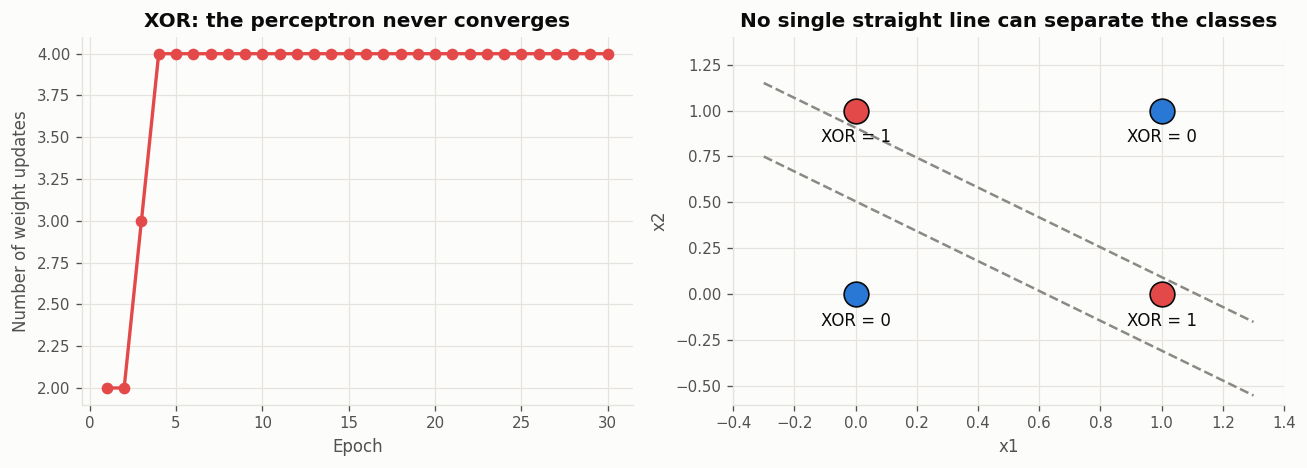

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(range(1, len(p_xor.errors_)+1), p_xor.errors_, marker="o", color=utils.RED)
ax.set_xlabel("Epoch"); ax.set_ylabel("Number of weight updates")
ax.set_title("XOR: the perceptron never converges"); utils.despine(ax)

ax = axes[1]
for x, t in zip(X_logic, y_xor):
    ax.scatter(x[0], x[1], s=220, color=utils.RED if t else utils.BLUE,
               edgecolor=utils.INK, zorder=5)
    ax.text(x[0], x[1]-0.17, f"XOR = {t}", ha="center", fontsize=10, color=utils.INK)
ax.plot([-0.3, 1.3], [1.15, -0.15], color=utils.MUTED, linestyle="--", linewidth=1.5)
ax.plot([-0.3, 1.3], [0.75, -0.55], color=utils.MUTED, linestyle="--", linewidth=1.5)
ax.set_xlim(-0.4, 1.4); ax.set_ylim(-0.6, 1.4)
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title("No single straight line can separate the classes")
utils.despine(ax)
plt.tight_layout()
utils.save_fig(fig, "07_xor_problem.png")
plt.show()

The solution is to stack units into **layers**. A hidden layer of two units can
compute XOR as `(x1 OR x2) AND NOT (x1 AND x2)` - exactly the composition of
gates the perceptron already learned individually. That is the multilayer
network of Section 8, and training it requires the gradient descent of Section 7.

## 7. Gradient descent

The perceptron rule uses a hard threshold, which is not differentiable, so it
cannot be extended to multiple layers. Gradient descent replaces the threshold
with a smooth activation and minimises a differentiable error function:

$$ E(w) = \frac{1}{2}\sum_{d \in D} (t_d - o_d)^2 $$

The gradient $\nabla E(w)$ points in the direction of steepest increase, so the
weights are moved against it:

$$ w \leftarrow w - \eta \, \nabla E(w),
\qquad \frac{\partial E}{\partial w_i} = -\sum_d (t_d - o_d)\, x_{id} $$

The **learning rate** $\eta$ controls the step size: too small and convergence
is slow; too large and the updates overshoot and may diverge. The demonstration
below runs gradient descent on a simple squared-error surface at three learning
rates.

saved figure -> Results/figures/07_gradient_descent.png


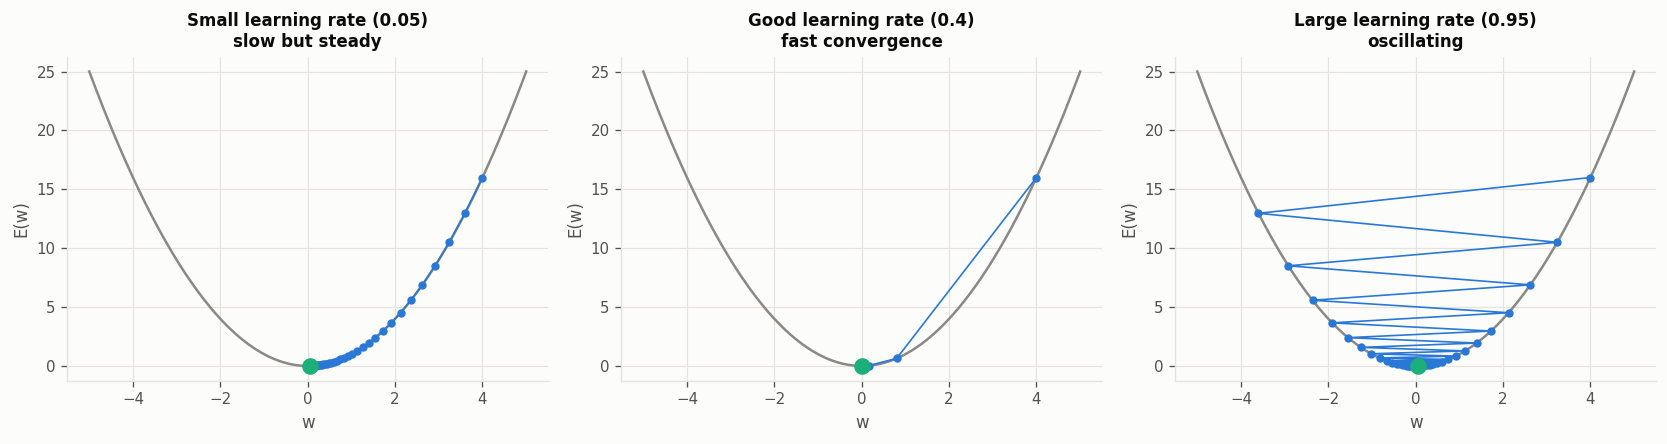

In [8]:
def gradient_descent_demo(lr, steps=40, start=4.0):
    """Minimise E(w) = w^2, whose gradient is 2w."""
    w = start; path = [w]
    for _ in range(steps):
        w = w - lr * (2 * w)
        path.append(w)
    return np.array(path)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, lr, title in zip(axes, [0.05, 0.4, 0.95],
                         ["Small learning rate (0.05)\nslow but steady",
                          "Good learning rate (0.4)\nfast convergence",
                          "Large learning rate (0.95)\noscillating"]):
    ws = np.linspace(-5, 5, 300)
    ax.plot(ws, ws**2, color=utils.MUTED, linewidth=1.5)
    path = gradient_descent_demo(lr)
    ax.plot(path, path**2, marker="o", markersize=4, color=utils.BLUE, linewidth=1)
    ax.scatter([path[-1]], [path[-1]**2], s=80, color=utils.GREEN, zorder=6)
    ax.set_title(title, fontsize=10); ax.set_xlabel("w"); ax.set_ylabel("E(w)")
    utils.despine(ax)
plt.tight_layout()
utils.save_fig(fig, "07_gradient_descent.png")
plt.show()

## 8. Multilayer networks and backpropagation

A multilayer network stacks layers of differentiable units. **Backpropagation**
trains it in two passes:

1. **Forward pass** - feed the input through the network and compute the output
   and the error.
2. **Backward pass** - propagate the error backwards using the chain rule,
   computing $\partial E / \partial w$ for every weight, then update the
   weights by gradient descent.

For an output unit $k$ the error term is
$\delta_k = o_k(1-o_k)(t_k - o_k)$, and for a hidden unit $h$ it is
$\delta_h = o_h(1-o_h)\sum_{k \in outputs} w_{kh}\delta_k$ - the hidden unit is
held responsible for error in proportion to its contribution to it.

First, the XOR problem that defeated the single perceptron:

In [9]:
from sklearn.neural_network import MLPClassifier

mlp_xor = MLPClassifier(hidden_layer_sizes=(4,), activation="tanh",
                        solver="lbfgs", max_iter=3000, random_state=SEED)
mlp_xor.fit(X_logic, y_xor)
pred = mlp_xor.predict(X_logic)

print("MULTILAYER NETWORK ON XOR (one hidden layer of 4 units)")
print("="*52)
print("   x1  x2 | target | network output")
print("  " + "-"*38)
for x, t, o in zip(X_logic, y_xor, pred):
    print(f"   {x[0]}   {x[1]}  |   {t}    |      {o}        "
          f"{'ok' if t == o else 'WRONG'}")
print(f"\n  all correct : {np.array_equal(pred, y_xor)}")
print("\n  The hidden layer solves what a single perceptron could not.")

MULTILAYER NETWORK ON XOR (one hidden layer of 4 units)
   x1  x2 | target | network output
  --------------------------------------
   0   0  |   0    |      0        ok
   0   1  |   1    |      1        ok
   1   0  |   1    |      1        ok
   1   1  |   0    |      0        ok

  all correct : True

  The hidden layer solves what a single perceptron could not.


saved figure -> Results/figures/07_mlp_xor_solved.png


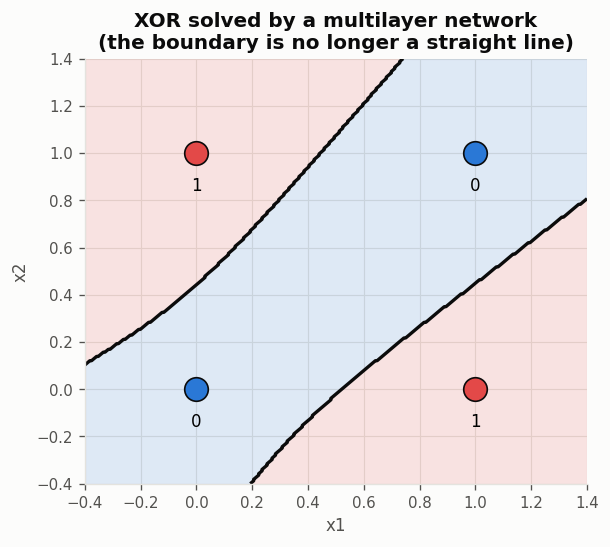

In [10]:
xx, yy = np.meshgrid(np.linspace(-0.4, 1.4, 300), np.linspace(-0.4, 1.4, 300))
Z = mlp_xor.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
fig, ax = plt.subplots(figsize=(5.4, 4.6))
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=[utils.BLUE, utils.RED], alpha=0.14)
ax.contour(xx, yy, Z, levels=[0.5], colors=[utils.INK], linewidths=2)
for x, t in zip(X_logic, y_xor):
    ax.scatter(x[0], x[1], s=200, color=utils.RED if t else utils.BLUE,
               edgecolor=utils.INK, zorder=5)
    ax.text(x[0], x[1]-0.16, str(t), ha="center", fontsize=10)
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title("XOR solved by a multilayer network\n(the boundary is no longer a straight line)")
utils.despine(ax)
utils.save_fig(fig, "07_mlp_xor_solved.png")
plt.show()

## 9. Multilayer network on the fraud data

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time

t0 = time.time()
mlp = Pipeline([
    ("scaler", StandardScaler()),     # essential - gradient descent needs comparable scales
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(32, 16),  # two hidden layers
        activation="relu",
        solver="adam",                # gradient descent with adaptive step sizes
        alpha=1e-4,                   # L2 regularisation, to limit overfitting
        batch_size=512,
        learning_rate_init=1e-3,
        max_iter=40,
        early_stopping=True,
        n_iter_no_change=5,
        validation_fraction=0.1,
        random_state=SEED)),
])
mlp.fit(X_train, y_train)
print(f"training time : {time.time()-t0:.1f} seconds")

net = mlp.named_steps["mlp"]
print(f"\narchitecture   : {X_train.shape[1]} inputs -> 32 -> 16 -> 1 output")
print(f"iterations run : {net.n_iter_}")
total_w = sum(w.size for w in net.coefs_) + sum(b.size for b in net.intercepts_)
print(f"weights learned: {total_w:,}")

training time : 2.2 seconds

architecture   : 30 inputs -> 32 -> 16 -> 1 output
iterations run : 8
weights learned: 1,537


saved figure -> Results/figures/07_training_loss.png


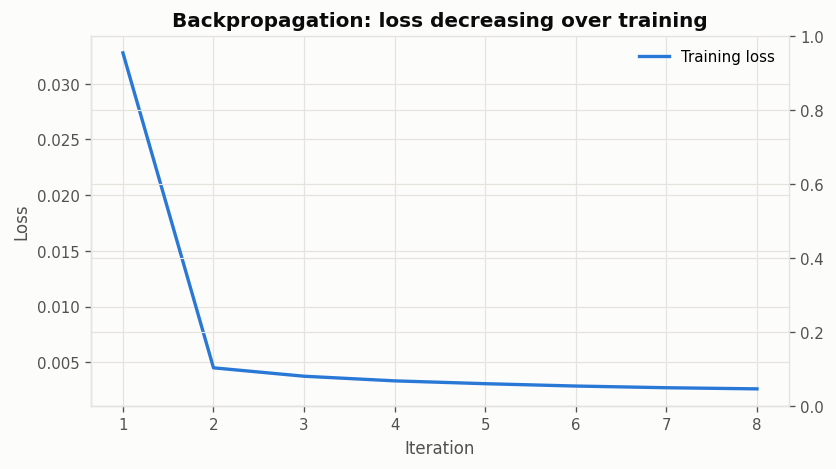

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(range(1, len(net.loss_curve_)+1), net.loss_curve_, color=utils.BLUE,
        label="Training loss")
if hasattr(net, "validation_scores_") and net.validation_scores_:
    ax2 = ax.twinx()
ax.set_xlabel("Iteration"); ax.set_ylabel("Loss")
ax.set_title("Backpropagation: loss decreasing over training")
ax.legend(); utils.despine(ax)
utils.save_fig(fig, "07_training_loss.png")
plt.show()

In [13]:
y_pred  = mlp.predict(X_test)
y_proba = mlp.predict_proba(X_test)[:, 1]
res = utils.evaluate("Neural Network (MLP)", y_test, y_pred, y_proba,
                     unit="Unit IV - Multilayer networks, backpropagation")
res["architecture"] = "30 -> 32 -> 16 -> 1"
res["n_weights"] = int(total_w)
utils.save_result(res, y_proba)


===== Neural Network (MLP) =====
syllabus  : Unit IV - Multilayer networks, backpropagation
accuracy  : 0.99945
precision : 0.9204
recall    : 0.7324
f1-score  : 0.8157
PR-AUC    : 0.8498
ROC-AUC   : 0.9773
confusion : TN=84,967  FP=9  FN=38  TP=104

              precision    recall  f1-score   support

  Legitimate     0.9996    0.9999    0.9997     84976
       Fraud     0.9204    0.7324    0.8157       142

    accuracy                         0.9994     85118
   macro avg     0.9600    0.8661    0.9077     85118
weighted avg     0.9994    0.9994    0.9994     85118

saved result -> Results/tables/neural_network_mlp.json


saved figure -> Results/figures/07_confusion.png


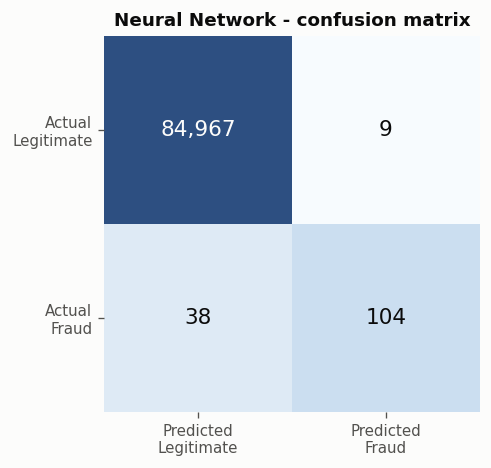

saved figure -> Results/figures/07_pr_curve.png


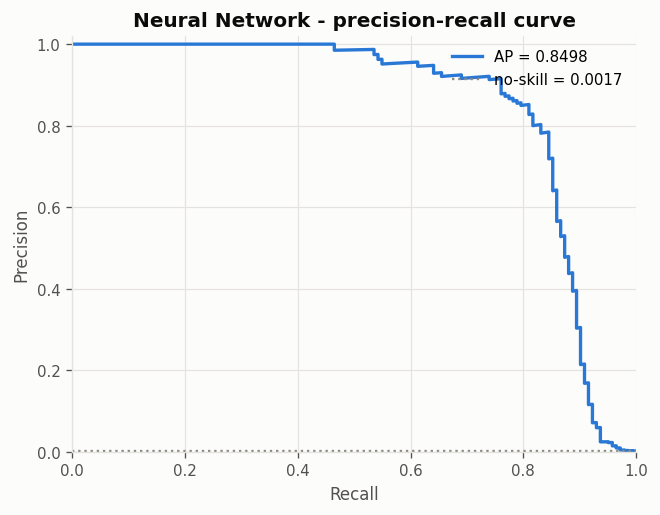

In [14]:
utils.plot_confusion(y_test, y_pred, "Neural Network - confusion matrix",
                     "07_confusion.png"); plt.show()
utils.plot_pr_curve(y_test, y_proba, "Neural Network - precision-recall curve",
                    "07_pr_curve.png"); plt.show()

## 10. A single perceptron on the fraud data, for comparison

How much does the hidden layer actually buy us on the real problem?

In [15]:
from sklearn.linear_model import Perceptron as SkPerceptron
from sklearn.metrics import f1_score, recall_score, precision_score

perc = Pipeline([("scaler", StandardScaler()),
                 ("p", SkPerceptron(max_iter=1000, tol=1e-3,
                                    random_state=SEED))])
perc.fit(X_train, y_train)
pp = perc.predict(X_test)

print(f"{'model':<28}{'precision':>11}{'recall':>9}{'f1':>9}")
print("-"*57)
print(f"{'Single perceptron':<28}{precision_score(y_test, pp, zero_division=0):>11.4f}"
      f"{recall_score(y_test, pp):>9.4f}{f1_score(y_test, pp):>9.4f}")
print(f"{'Multilayer network (MLP)':<28}{res['precision']:>11.4f}"
      f"{res['recall']:>9.4f}{res['f1']:>9.4f}")

res_p = utils.evaluate("Perceptron", y_test, pp, None,
                       unit="Unit IV - Perceptron learning", show=False)
utils.save_result(res_p)
print("\nsaved the perceptron result for the Notebook 10 comparison")

model                         precision   recall       f1
---------------------------------------------------------
Single perceptron                0.6761   0.8380   0.7484
Multilayer network (MLP)         0.9204   0.7324   0.8157
saved result -> Results/tables/perceptron.json

saved the perceptron result for the Notebook 10 comparison


## 11. Computational learning theory and VC dimension

Unit IV closes with the question of how many examples a learner needs.

**Sample complexity** asks: how many training examples guarantee, with
probability at least $1-\delta$, that the learned hypothesis has true error at
most $\epsilon$? For a **finite hypothesis space** $H$, the PAC bound is

$$ m \ge \frac{1}{\epsilon}\left(\ln|H| + \ln\frac{1}{\delta}\right) $$

Most interesting hypothesis spaces are infinite, so $|H|$ is useless. The
**VC dimension** replaces it: VC(H) is the size of the largest set of points
that H can **shatter** - label in all possible ways. The bound becomes

$$ m \ge \frac{1}{\epsilon}\left(4\log_2\frac{2}{\delta} + 8\,VC(H)\log_2\frac{13}{\epsilon}\right) $$

| Hypothesis space | VC dimension |
|---|---|
| Single perceptron in $d$ dimensions | $d + 1$ |
| Our perceptron ($d = 30$) | 31 |
| Neural network with $W$ weights | roughly $O(W \log W)$ |
| Our MLP | in the low thousands |

This has a direct and uncomfortable implication for our project.

In [16]:
import math

def pac_sample_size(vc, eps=0.05, delta=0.05):
    return (1/eps) * (4*math.log2(2/delta) + 8*vc*math.log2(13/eps))

d = X_train.shape[1]
vc_perceptron = d + 1
vc_mlp_approx = total_w * math.log2(max(total_w, 2)) / 10   # rough order-of-magnitude

print("SAMPLE COMPLEXITY (epsilon = 0.05, delta = 0.05)")
print("="*58)
for name, vc in [("Single perceptron", vc_perceptron),
                 ("MLP (rough estimate)", vc_mlp_approx)]:
    m = pac_sample_size(vc)
    print(f"  {name:<24} VC ~ {vc:>9.0f}   examples needed ~ {m:>12,.0f}")

print(f"\n  Training examples available    : {len(y_train):>12,}")
print(f"  Of which FRAUD examples        : {int(np.asarray(y_train).sum()):>12,}")

SAMPLE COMPLEXITY (epsilon = 0.05, delta = 0.05)
  Single perceptron        VC ~        31   examples needed ~       40,217
  MLP (rough estimate)     VC ~      1627   examples needed ~    2,088,877

  Training examples available    :      198,608
  Of which FRAUD examples        :          331


The bound is loose - PAC bounds usually are - but the message survives. We have
roughly 200,000 training examples in total, which is comfortable, but only
**331 of them are frauds**. The minority class is where the model actually has
to learn a boundary, and there the effective sample size is tiny relative to the
capacity of a network with thousands of weights.

This is the theoretical justification for several choices already made in this
project: regularisation (`alpha`), early stopping, keeping the network small,
and preferring the simpler models when their performance is comparable. It also
explains why the very high-capacity models do not dominate the comparison in
Notebook 10 the way one might expect.

## 12. Summary

- The McCulloch-Pitts neuron computes AND and OR with hand-set weights but
  cannot learn.
- The perceptron learning rule learns AND, OR, NAND and NOR from examples, and
  converges because each is linearly separable.
- It **fails on XOR** and never converges, because a single hyperplane cannot
  separate the classes - the limitation that stalled the field for a decade.
- Gradient descent replaces the hard threshold with a differentiable objective;
  the learning rate governs whether it converges smoothly, slowly, or oscillates.
- A multilayer network trained by backpropagation solves XOR and produces a
  competitive fraud classifier.
- VC dimension and the PAC bound explain why network capacity has to be
  restrained here: only 331 fraud examples are available to constrain thousands
  of weights.